## Simple Text Classification (Sentiment Analysis)

### Custom RNN Class

In [ ]:
texts = [
    "i love this movie",
    "this film is amazing",
    "i hate this movie",
    "this film is terrible",
    "i really love this",
    "i really hate this"
]

labels = [1, 1, 0, 0, 1, 0]  # 1 = positive, 0 = negative

Text preprocessing

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Dense, Layer
from tensorflow.keras.models import Model
from tensorflow.keras import initializers
from tensorflow.keras.optimizers import Adam

In [ ]:
max_words = 1000
max_len = 5  # number of time steps (like n_step)

tokenizer = Tokenizer(num_words=max_words, oov_token="<UNK>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
x_train = pad_sequences(sequences, maxlen=max_len)
y_train = np.array(labels)
x_train.shape, y_train.shape

((6, 5), (6,))

In [ ]:
tokenizer.fit_on_texts(texts)

In [ ]:
sequences

[[3, 4, 2, 5],
 [2, 6, 7, 10],
 [3, 8, 2, 5],
 [2, 6, 7, 11],
 [3, 9, 4, 2],
 [3, 9, 8, 2]]

In [ ]:
x_train

array([[ 0,  3,  4,  2,  5],
       [ 0,  2,  6,  7, 10],
       [ 0,  3,  8,  2,  5],
       [ 0,  2,  6,  7, 11],
       [ 0,  3,  9,  4,  2],
       [ 0,  3,  9,  8,  2]], dtype=int32)

Convert word indices → one-hot vectors

In [ ]:
vocab_size = len(tokenizer.word_index) + 1

x_train_oh = tf.one_hot(x_train, depth=vocab_size)
x_train_oh

<tf.Tensor: shape=(6, 5, 12), dtype=float32, numpy=
array([[[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]],

       [[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]],

       [[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]],

       [[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0

In [ ]:
# Input (N, T, Dim)
# (batch, time_steps, features) - (6, 5, vocab_size)

A Custom RNN Class

In [ ]:
class MySimpleRNN(Layer):
  def __init__(self, nf, nh):
      super().__init__()
      self.nh = nh
      self.nf = nf

      self.wx = self.add_weight(shape=(self.nf, self.nh), initializer="glorot_uniform", trainable=True, name="wx")
      self.wh = self.add_weight(shape=(self.nh, self.nh), initializer="glorot_uniform", trainable=True, name="wh")
      self.b = self.add_weight(shape=(1, self.nh), initializer="glorot_uniform", trainable=True, name="b")

  def call(self, x):
      h = tf.zeros((tf.shape(x)[0], self.nh))
      for t in range(x.shape[1]):  # static integer
          z = tf.matmul(x[:, t, :], self.wx) + \
              tf.matmul(h, self.wh) + self.b
          h = tf.math.tanh(z)
      return h

In [ ]:
n_feat = vocab_size
max_len = x_train.shape[1]
n_hidden = 32
n_output = 2  # positive / negative

x_input = Input(shape=(max_len, n_feat))
h = MySimpleRNN(n_feat, n_hidden)(x_input)
y_output = Dense(n_output, activation="softmax")(h)

model = Model(x_input, y_output)
model.compile(
    optimizer=Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 5, 12)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_simple_rnn_2 (MySimpleRNN)   │ (None, 32)             │         1,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,506 (5.88 KB)

 Trainable params: 1,506 (5.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist = model.fit(
    x_train_oh,
    y_train,
    epochs=50,
    batch_size=2
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.5000 - loss: 0.7336
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.3125 - loss: 0.7928     
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5625 - loss: 0.5891 
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5000 - loss: 0.6029
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5000 - loss: 0.5873
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6458 - loss: 0.5165
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8542 - loss: 0.5028
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9167 - loss: 0.5140
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8542 - loss: 0.5138
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7292 - loss: 0.5448
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.4524
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.

In [ ]:
def predict_text(text):
    seq = tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_len)
    seq_oh = tf.one_hot(seq, depth=vocab_size)

    pred = model.predict(seq_oh, verbose=0)
    return "positive" if np.argmax(pred) == 1 else "negative"

print(predict_text("i love this film"))
print(predict_text("this movie is terrible"))

positive
positive


### Building model using RNN Layer

In [ ]:
texts = [
    "i love this movie",
    "this film is terrible",
    "amazing acting and story",
    "worst movie ever",
    "i enjoyed the film",
    "bad acting"
]

labels = [1, 0, 1, 0, 1, 0]   # 1 = positive, 0 = negative

Tokenization and padding

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

max_len = 6   # fixed time steps (like n_step)
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

x_train = pad_sequences(sequences, maxlen=max_len, padding="post")
y_train = np.array(labels)

In [ ]:
x_train.shape

(6, 6)

One-hot encoding

In [ ]:
x_train_oh = np.zeros((x_train.shape[0], max_len, vocab_size))

for i, seq in enumerate(x_train):
    for t, word_id in enumerate(seq):
        if word_id != 0:
            x_train_oh[i, t, word_id] = 1.0

SimpleRNN Layer

In [ ]:
from tensorflow.keras.layers import Dense, Input, SimpleRNN
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

n_feat = vocab_size
n_hidden = 32
n_output = 1

In [ ]:
x_input = Input(shape=(max_len, n_feat))
h = SimpleRNN(n_hidden, activation="tanh")(x_input)
y_output = Dense(n_output, activation="sigmoid")(h)

model = Model(x_input, y_output)
model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 6, 17)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,633 (6.38 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 0 (0.00 B)

Training

In [ ]:
hist = model.fit(
    x_train_oh,
    y_train,
    epochs=30,
    batch_size=2,
    verbose=1
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5625 - loss: 0.7130
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5000 - loss: 0.6699
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7083 - loss: 0.5701
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8542 - loss: 0.5567
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7292 - loss: 0.5498
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.4619
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.4424
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.4082
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.3211
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.3015
Epoch 11/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.2465
Epoch 12/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.2341
E

Prediction

In [ ]:
def predict_text(text):
    seq = tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_len, padding="post")

    oh = np.zeros((1, max_len, vocab_size))
    for t, word_id in enumerate(seq[0]):
        if word_id != 0:
            oh[0, t, word_id] = 1.0

    prob = model.predict(oh, verbose=0)[0][0]
    return "Positive" if prob > 0.5 else "Negative"

print(predict_text("i love this film"))
print(predict_text("worst acting ever"))

Positive
Negative


### Build model using LSTM Custom class

In [ ]:
texts = [
    "i love this movie",
    "this film is great",
    "amazing experience",
    "i hate this movie",
    "this film is terrible",
    "worst experience ever"
]

labels = [1, 1, 1, 0, 0, 0]  # 1=positive, 0=negative

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

In [ ]:
max_len = 6

tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=max_len, padding="post")

y = np.array(labels)

vocab_size = len(tokenizer.word_index) + 1

In [ ]:
X

array([[ 2,  7,  1,  3,  0,  0],
       [ 1,  4,  5,  8,  0,  0],
       [ 9,  6,  0,  0,  0,  0],
       [ 2, 10,  1,  3,  0,  0],
       [ 1,  4,  5, 11,  0,  0],
       [12,  6, 13,  0,  0,  0]], dtype=int32)

In [ ]:
X_oh = tf.one_hot(X, depth=vocab_size)
X_oh

<tf.Tensor: shape=(6, 6, 14), dtype=float32, numpy=
array([[[0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

       [[0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

       [[0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0.,

Custom LSTM Layer

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Dense

class MyLSTM(Layer):
    def __init__(self, hidden_units):
        super().__init__()
        self.hidden_units = hidden_units

        # Gates for input x
        self.Wf = Dense(hidden_units)
        self.Wi = Dense(hidden_units)
        self.Wc = Dense(hidden_units)
        self.Wo = Dense(hidden_units)

        # Gates for hidden state h (no bias)
        self.Rf = Dense(hidden_units, use_bias=False)
        self.Ri = Dense(hidden_units, use_bias=False)
        self.Rc = Dense(hidden_units, use_bias=False)
        self.Ro = Dense(hidden_units, use_bias=False)

    def call(self, x):
        batch_size = tf.shape(x)[0]
        time_steps = x.shape[1]  # STATIC length

        h = tf.zeros((batch_size, self.hidden_units))
        c = tf.zeros((batch_size, self.hidden_units))

        for t in range(time_steps):  # Python int loop
            xt = x[:, t, :]

            f = tf.sigmoid(self.Wf(xt) + self.Rf(h))
            i = tf.sigmoid(self.Wi(xt) + self.Ri(h))
            c_hat = tf.tanh(self.Wc(xt) + self.Rc(h))
            o = tf.sigmoid(self.Wo(xt) + self.Ro(h))

            c = f * c + i * c_hat
            h = o * tf.tanh(c)

        return h

In [ ]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

hidden_units = 32

x_input = Input(shape=(max_len, vocab_size))
h = MyLSTM(hidden_units)(x_input)
y_output = Dense(1, activation="sigmoid")(h)

model = Model(x_input, y_output)

model.compile(
    optimizer=Adam(0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 6, 14)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_lstm_1 (MyLSTM)              │ (None, 32)             │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,049 (23.63 KB)

 Trainable params: 6,049 (23.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist = model.fit(
    X_oh,
    y,
    epochs=50,
    batch_size=2,
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0020
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0019 
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0020 
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0023
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0022
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0019
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0020
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0021
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0017
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0019
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0021
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0021

Prediction

In [ ]:
def predict_sentiment(sentence):
    seq = tokenizer.texts_to_sequences([sentence])
    pad = pad_sequences(seq, maxlen=max_len)
    oh = tf.one_hot(pad, depth=vocab_size)
    prob = model.predict(oh)[0][0]
    return "Positive" if prob > 0.5 else "Negative"

print(predict_sentiment("i love this film"))
print(predict_sentiment("this movie is terrible"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Positive


### Building Model using LSTM layer

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

In [ ]:
texts = [
    "this movie is great",
    "I love this film",
    "awesome experience",
    "bad movie",
    "I hate this film",
    "terrible acting"
]

labels = np.array([1, 1, 1, 0, 0, 0])  # 1 = positive, 0 = negative

Tokenization & padding

In [ ]:
vocab_size = 100
max_len = 6
embedding_dim = 16

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
x_train = pad_sequences(sequences, maxlen=max_len, padding="post")
y_train = labels

Built-in LSTM layer

In [ ]:
hidden_units = 32

x_input = Input(shape=(max_len,))
x_embed = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    input_length=max_len
)(x_input)

h = LSTM(hidden_units)(x_embed)
y_output = Dense(1, activation="sigmoid")(h)

model = Model(x_input, y_output)
model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 6, 16)          │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,905 (30.88 KB)

 Trainable params: 7,905 (30.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=2
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4167 - loss: 0.6956
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5000 - loss: 0.6937
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5000 - loss: 0.6929
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4375 - loss: 0.6942
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6458 - loss: 0.6922
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9167 - loss: 0.6914
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7292 - loss: 0.6920
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5833 - loss: 0.6915
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6458 - loss: 0.6903
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7292 - loss: 0.6897 
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.6880
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.6857


 Prediction

In [ ]:
test_texts = [
    "I love this movie",
    "this film is terrible"
]

test_seq = tokenizer.texts_to_sequences(test_texts)
test_pad = pad_sequences(test_seq, maxlen=max_len, padding="post")

pred = model.predict(test_pad)

for t, p in zip(test_texts, pred):
    print(t, "→", "Positive" if p > 0.5 else "Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
I love this movie → Positive
this film is terrible → Positive


### Building model using Peephole LSTM

In [ ]:
texts = [
    "i love this movie",
    "this film is great",
    "amazing acting",
    "i hate this movie",
    "this film is terrible",
    "bad acting"
]

labels = [1, 1, 1, 0, 0, 0]  # 1 = positive, 0 = negative

Tokenization & Padding

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

max_len = 6

tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
x_data = pad_sequences(sequences, maxlen=max_len)
y_data = np.array(labels)

vocab_size = len(tokenizer.word_index) + 1

Peephole LSTM

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Layer

class PeepholeLSTM(Layer):
    def __init__(self, hidden_units):
        super().__init__()
        self.hidden_units = hidden_units

        self.Wf = Dense(hidden_units)
        self.Wi = Dense(hidden_units)
        self.Wc = Dense(hidden_units)
        self.Wo = Dense(hidden_units)

        self.Rf = Dense(hidden_units, use_bias=False)
        self.Ri = Dense(hidden_units, use_bias=False)
        self.Rc = Dense(hidden_units, use_bias=False)
        self.Ro = Dense(hidden_units, use_bias=False)

        self.Pf = Dense(hidden_units, use_bias=False)
        self.Pi = Dense(hidden_units, use_bias=False)
        self.Po = Dense(hidden_units, use_bias=False)

    def call(self, x):
        batch_size = tf.shape(x)[0]
        h = tf.zeros((batch_size, self.hidden_units))
        c = tf.zeros((batch_size, self.hidden_units))

        # FIXED LOOP
        for t in range(x.shape[1]):
            xt = x[:, t, :]
            f = tf.sigmoid(self.Wf(xt) + self.Rf(h) + self.Pf(c))
            i = tf.sigmoid(self.Wi(xt) + self.Ri(h) + self.Pi(c))
            c_hat = tf.tanh(self.Wc(xt) + self.Rc(h))
            c = f * c + i * c_hat
            o = tf.sigmoid(self.Wo(xt) + self.Ro(h) + self.Po(c))
            h = o * tf.tanh(c)

        return h

Build Sentiment Classification

In [ ]:
from tensorflow.keras.layers import Input, Embedding
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

embedding_dim = 16
hidden_units = 32

x_input = Input(shape=(max_len,))
x_embed = Embedding(vocab_size, embedding_dim)(x_input)

h = PeepholeLSTM(hidden_units)(x_embed)
y_output = Dense(1, activation="sigmoid")(h)

model = Model(x_input, y_output)
model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(0.01),
    metrics=["accuracy"]
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 6, 16)          │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ peephole_lstm (PeepholeLSTM)    │ (None, 32)             │         9,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,977 (42.88 KB)

 Trainable params: 10,977 (42.88 KB)

 Non-trainable params: 0 (0.00 B)

Train the Model

In [ ]:
history = model.fit(
    x_data,
    y_data,
    epochs=30,
    batch_size=2,
    verbose=1
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.2708 - loss: 0.6993
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4583 - loss: 0.6944    
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.6769
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.6611
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.6369
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.5824
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.4708
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.2690
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.1108
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0462
Epoch 11/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0283
Epoch 12/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.02

Prediction

In [ ]:
test_text = ["this movie is amazing"]
test_seq = tokenizer.texts_to_sequences(test_text)
test_pad = pad_sequences(test_seq, maxlen=max_len)

prediction = model.predict(test_pad)
print("Sentiment:", "Positive" if prediction[0][0] > 0.5 else "Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step
Sentiment: Positive


### Building Model using Custom GRU Class

In [ ]:
texts = [
    "I love this movie",
    "This film was amazing",
    "I hate this movie",
    "This film was terrible",
    "Amazing acting and story",
    "Worst movie ever"
]

labels = [1, 1, 0, 0, 1, 0]  # 1 = positive, 0 = negative

Tokenization & Padding

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

max_len = 6

tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
x_data = pad_sequences(sequences, maxlen=max_len, padding="post")

y_data = np.array(labels)

vocab_size = len(tokenizer.word_index) + 1

Custom GRU Layer

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Dense

class MyGRU(Layer):
    def __init__(self, hidden_units):
        super().__init__()
        self.hidden_units = hidden_units

        self.Wr = Dense(hidden_units)
        self.Wz = Dense(hidden_units)
        self.Wg = Dense(hidden_units)

        self.Ur = Dense(hidden_units, use_bias=False)
        self.Uz = Dense(hidden_units, use_bias=False)
        self.Ug = Dense(hidden_units, use_bias=False)

    def call(self, x):
        batch_size = tf.shape(x)[0]
        h = tf.zeros((batch_size, self.hidden_units))

        time_steps = x.shape[1]  # STATIC → SAFE

        for t in range(time_steps):
            xt = x[:, t, :]
            r = tf.sigmoid(self.Wr(xt) + self.Ur(h))
            z = tf.sigmoid(self.Wz(xt) + self.Uz(h))
            g = tf.tanh(self.Wg(xt) + self.Ug(r * h))
            h = (1 - z) * h + z * g

        return h

Sentiment Classification Model

In [ ]:
from tensorflow.keras.layers import Input, Dense, Embedding
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

embedding_dim = 16
hidden_units = 32

x_input = Input(shape=(max_len,))
x_embed = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim
)(x_input)

h = MyGRU(hidden_units)(x_embed)
y_output = Dense(1, activation="sigmoid")(h)

model = Model(x_input, y_output)
model.compile(
    optimizer=Adam(0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 6, 16)          │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_gru (MyGRU)                  │ (None, 32)             │         4,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,977 (19.44 KB)

 Trainable params: 4,977 (19.44 KB)

 Non-trainable params: 0 (0.00 B)

Training

In [ ]:
history = model.fit(
    x_data,
    y_data,
    epochs=30,
    batch_size=2
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2708 - loss: 0.7044
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5000 - loss: 0.6838
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.6722
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9167 - loss: 0.6320
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.5376
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.3799
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.1306
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0397
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0050
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0044
Epoch 11/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 6.2416e-04
Epoch 12/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 4.50

Prediction

In [ ]:
def predict_sentiment(sentence):
    seq = tokenizer.texts_to_sequences([sentence])
    pad = pad_sequences(seq, maxlen=max_len, padding="post")
    prob = model.predict(pad)[0][0]
    return "Positive" if prob > 0.5 else "Negative"

In [ ]:
print(predict_sentiment("I love this film"))
print(predict_sentiment("This movie was horrible"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 957ms/step
Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Negative


### Building Model using Keras GRU Layer

In [ ]:
texts = [
    "I love this movie",
    "This film was amazing",
    "I hate this movie",
    "This film was terrible",
    "Amazing acting and story",
    "Worst movie ever"
]

labels = [1, 1, 0, 0, 1, 0]

Tokenization & Padding

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

max_len = 6

tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
x_data = pad_sequences(sequences, maxlen=max_len, padding="post")

y_data = np.array(labels)

vocab_size = len(tokenizer.word_index) + 1

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, GRU, Dense
from tensorflow.keras.optimizers import Adam

embedding_dim = 16
hidden_units = 32

x_input = Input(shape=(max_len,))
x_embed = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim
)(x_input)

h = GRU(hidden_units)(x_embed)  # BUILT-IN GRU
y_output = Dense(1, activation="sigmoid")(h)

model = Model(x_input, y_output)

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 6, 16)          │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,073 (19.82 KB)

 Trainable params: 5,073 (19.82 KB)

 Non-trainable params: 0 (0.00 B)

Training

In [ ]:
history = model.fit(
    x_data,
    y_data,
    epochs=30,
    batch_size=2
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5000 - loss: 0.6950
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4375 - loss: 0.7014
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8542 - loss: 0.6828
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8542 - loss: 0.6640
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.6111
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.4887
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.1912 
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0863
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0133
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0022
Epoch 11/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 4.5864e-04
Epoch 12/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 7.4

Prediction

In [ ]:
def predict_sentiment(sentence):
    seq = tokenizer.texts_to_sequences([sentence])
    pad = pad_sequences(seq, maxlen=max_len, padding="post")
    prob = model.predict(pad, verbose=0)[0][0]
    return "Positive" if prob > 0.5 else "Negative"

In [ ]:
print(predict_sentiment("I love this film"))
print(predict_sentiment("This movie was horrible"))

Positive
Negative


## POS Tagging

Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

````
Treebank:  3,914 sentences (Wall Street Journal news)
Brown:    57,340 sentences (mixed genres - news, fiction, etc.)
Conll2000:  21,268 sentences (transcribed conversations)

Total: ~75k tagged sentences → Suitable for POS tagging! Model
````

In [ ]:
import nltk
from nltk.corpus import brown
from nltk.corpus import treebank
from nltk.corpus import conll2000
nltk.download('treebank')
nltk.download('brown')
nltk.download('conll2000')
nltk.download('universal_tagset')

[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Unzipping corpora/treebank.zip.
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.


True

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.8 MB/s eta 0:00:00


In [ ]:
from gensim.models import KeyedVectors

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import Sequential, Input, Model
from tensorflow.keras.layers import Embedding, Dense, TimeDistributed, LSTM, GRU, Bidirectional, SimpleRNN, RNN
from tensorflow.keras.preprocessing.text import Tokenizer

Load data: Corpus from NLTK

In [ ]:
treebank.tagged_words()

[('Pierre', 'NNP'), ('Vinken', 'NNP'), (',', ','), ...]

In [ ]:
treebank.tagged_words(tagset='universal')

[('Pierre', 'NOUN'), ('Vinken', 'NOUN'), (',', '.'), ...]

In [ ]:
treebank.tagged_sents()

[[('Pierre', 'NNP'), ('Vinken', 'NNP'), (',', ','), ('61', 'CD'), ('years', 'NNS'), ('old', 'JJ'), (',', ','), ('will', 'MD'), ('join', 'VB'), ('the', 'DT'), ('board', 'NN'), ('as', 'IN'), ('a', 'DT'), ('nonexecutive', 'JJ'), ('director', 'NN'), ('Nov.', 'NNP'), ('29', 'CD'), ('.', '.')], [('Mr.', 'NNP'), ('Vinken', 'NNP'), ('is', 'VBZ'), ('chairman', 'NN'), ('of', 'IN'), ('Elsevier', 'NNP'), ('N.V.', 'NNP'), (',', ','), ('the', 'DT'), ('Dutch', 'NNP'), ('publishing', 'VBG'), ('group', 'NN'), ('.', '.')], ...]

In [ ]:
treebank.tagged_sents(tagset='universal')

[[('Pierre', 'NOUN'), ('Vinken', 'NOUN'), (',', '.'), ('61', 'NUM'), ('years', 'NOUN'), ('old', 'ADJ'), (',', '.'), ('will', 'VERB'), ('join', 'VERB'), ('the', 'DET'), ('board', 'NOUN'), ('as', 'ADP'), ('a', 'DET'), ('nonexecutive', 'ADJ'), ('director', 'NOUN'), ('Nov.', 'NOUN'), ('29', 'NUM'), ('.', '.')], [('Mr.', 'NOUN'), ('Vinken', 'NOUN'), ('is', 'VERB'), ('chairman', 'NOUN'), ('of', 'ADP'), ('Elsevier', 'NOUN'), ('N.V.', 'NOUN'), (',', '.'), ('the', 'DET'), ('Dutch', 'NOUN'), ('publishing', 'VERB'), ('group', 'NOUN'), ('.', '.')], ...]

In [ ]:
# Load tagged sentences with Universal tagset (15 simplified tags)
treebank_corpus = treebank.tagged_sents(tagset='universal')
brown_corpus    = brown.tagged_sents(tagset='universal')
conll2000_corpus = conll2000.tagged_sents(tagset='universal')

# Combine all corpora into single training dataset
tagged_sentences = treebank_corpus + brown_corpus + conll2000_corpus

print(f"Total sentences: {len(tagged_sentences):,}")
print(f"Sample: {tagged_sentences[0][:5]}")  # First 5 words of first sentence

Total sentences: 72,202
Sample: [('Pierre', 'NOUN'), ('Vinken', 'NOUN'), (',', '.'), ('61', 'NUM'), ('years', 'NOUN')]


**Many-to-Many Problem Structure**

**Each data point = One complete sentence** (sequence-to-sequence):

| **Input Sequence (X)** | **Output Sequence (Y)** |
|-----------------------|-------------------------|
| `["Apple", "released", "new", "iPhones", "today"]` | `["NOUN", "VERB", "ADJ", "NOUN", "NOUN"]` |
| `["The", "weather", "is", "perfect", "now"]` | `["DET", "NOUN", "VERB", "ADJ", "ADV"]` |
| `["Engineers", "built", "this", "amazing", "bridge"]` | `["NOUN", "VERB", "DET", "ADJ", "NOUN"]` |

In [ ]:
# Convert tagged sentences to X (words) and Y (tags) sequences
X = []  # Input sequences: list of sentences (words only)
Y = []  # Output sequences: list of sentences (tags only)

In [ ]:
for sentence in tagged_sentences:  # 72,202 iterations
    # sentence = [('Apple', 'NOUN'), ('released', 'VERB'), ...]

    words = []  # Clean words only
    tags = []   # POS tags only

    for word_tag_pair in sentence:
        words.append(word_tag_pair[0])     # 'Apple'
        tags.append(word_tag_pair[1])      # 'NOUN'

    X.append(words)  # X[0] = ['Apple', 'released', 'new', ...]
    Y.append(tags)   # Y[0] = ['NOUN', 'VERB', 'ADJ', ...]

print(f"Total sentences: {len(X)}")
print(f"Sample shapes - X[0]: {len(X[0])} words, Y[0]: {len(Y[0])} tags")
print(f"Example: X[0][:8] → {X[0][:8]}")
print(f"         Y[0][:8] → {Y[0][:8]}")

Total sentences: 72202
Sample shapes - X[0]: 18 words, Y[0]: 18 tags
Example: X[0][:8] → ['Pierre', 'Vinken', ',', '61', 'years', 'old', ',', 'will']
         Y[0][:8] → ['NOUN', 'NOUN', '.', 'NUM', 'NOUN', 'ADJ', '.', 'VERB']


In [ ]:
# Calculate vocabulary size and tagset size
num_words = len(set(word.lower() for sentence in X for word in sentence))
num_tags  = len(set(tag for sentence in Y for tag in sentence))  # FIXED: tags, not words!

print(f"Total tagged sentences: {len(X):,}")
print(f"Vocabulary size:        {num_words:,}")
print(f"Number of unique tags:  {num_tags:,}")

Total tagged sentences: 72,202
Vocabulary size:        59,448
Number of unique tags:  12


Many-to-Many Sequence Alignment

In [ ]:
# Examine first data point (one complete sentence)
print(f"Input sequence (X[0]):  {X[0]}")
print(f"Output sequence (Y[0]): {Y[0]}")

Input sequence (X[0]):  ['Pierre', 'Vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'Nov.', '29', '.']
Output sequence (Y[0]): ['NOUN', 'NOUN', '.', 'NUM', 'NOUN', 'ADJ', '.', 'VERB', 'VERB', 'DET', 'NOUN', 'ADP', 'DET', 'ADJ', 'NOUN', 'NOUN', 'NUM', '.']


In [ ]:
# Verify sequence alignment (critical for many-to-many!)
print(f"Input length:  {len(X[0])} words")
print(f"Output length: {len(Y[0])} tags")
print(f"Length match: {len(X[0]) == len(Y[0])}")

Input length:  18 words
Output length: 18 tags
Length match: True


In [ ]:
# Word ↔ Tag alignment check
print("\nWord ↔ Tag Pairs:")
for i, (word, tag) in enumerate(zip(X[0][:10], Y[0][:10]), 1):  # First 10 pairs
    print(f"  {i:2d}. '{word}' → {tag}")


Word ↔ Tag Pairs:
   1. 'Pierre' → NOUN
   2. 'Vinken' → NOUN
   3. ',' → .
   4. '61' → NUM
   5. 'years' → NOUN
   6. 'old' → ADJ
   7. ',' → .
   8. 'will' → VERB
   9. 'join' → VERB
  10. 'the' → DET


Convert Words/Tags → Integer IDs

Input:  ['Pierre', 'Vinken', ',', '61', ...]
Process:
1. fit_on_texts(X) → {'pierre':1, 'vinken':2, ',':3, '61':4, ...}
2. texts_to_sequences() → [1, 2, 3, 4, ...]

Case-insensitive (handled earlier with .lower())

`<UNK>` for rare words (out-of-vocab)


In [ ]:
# Feature Encoding
word_tokenizer = Tokenizer(num_words=20_000, oov_token='<UNK>')  # 20K vocab + OOV
word_tokenizer.fit_on_texts(X)
X_encoded = word_tokenizer.texts_to_sequences(X)
X_encoded[0]

[6424,
 1,
 3,
 7653,
 103,
 171,
 3,
 48,
 1899,
 2,
 270,
 18,
 8,
 13231,
 620,
 1712,
 2762,
 4]

Input:  ['NOUN', 'NOUN', '.', 'NUM', ...]
Process:
1. fit_on_texts(Y) → {'NOUN':1, '.':2, 'VERB':3, 'NUM':4, ...}
2. texts_to_sequences() → [1, 1, 2, 4, ...]

Universal tags → Small vocab (12 tags typically)


In [ ]:
# Target Encoding
tag_tokenizer = Tokenizer(num_words=None, oov_token='<UNK>')     # All unique tags
tag_tokenizer.fit_on_texts(Y)
Y_encoded = tag_tokenizer.texts_to_sequences(Y)
Y_encoded[0]

[2, 2, 4, 12, 2, 7, 4, 3, 3, 6, 2, 5, 6, 7, 2, 2, 12, 4]

In [ ]:
print(f"Word vocab size:  {len(word_tokenizer.word_index)}")
print(f"Tag vocab size:   {len(tag_tokenizer.word_index)}")

Word vocab size:  59449
Tag vocab size:   13


In [ ]:
# Reverse mappings for debugging
word_to_id = word_tokenizer.word_index
id_to_word = {v: k for k, v in word_to_id.items()}
tag_to_id  = tag_tokenizer.word_index
id_to_tag  = {v: k for k, v in tag_to_id.items()}

print("Words:  'the':", word_to_id.get('the', 'UNK'), f"→ '{id_to_word.get(4, 'UNK')}'")
print("Tags:   'NOUN':", tag_to_id.get('NOUN', 'UNK'), f"→ '{id_to_tag.get(1, 'UNK')}'")

Words:  'the': 2 → '.'
Tags:   'NOUN': UNK → '<UNK>'


PAD Sequences

In [ ]:
# Analyze sequence lengths before padding
lengths = [len(seq) for seq in X_encoded]
print(f"Longest sentence: {max(lengths)} tokens")
print(f"Median length:    {np.median(lengths):.1f} tokens")
print(f"95th percentile:  {np.percentile(lengths, 95):.1f} tokens")

Longest sentence: 271 tokens
Median length:    19.0 tokens
95th percentile:  44.0 tokens


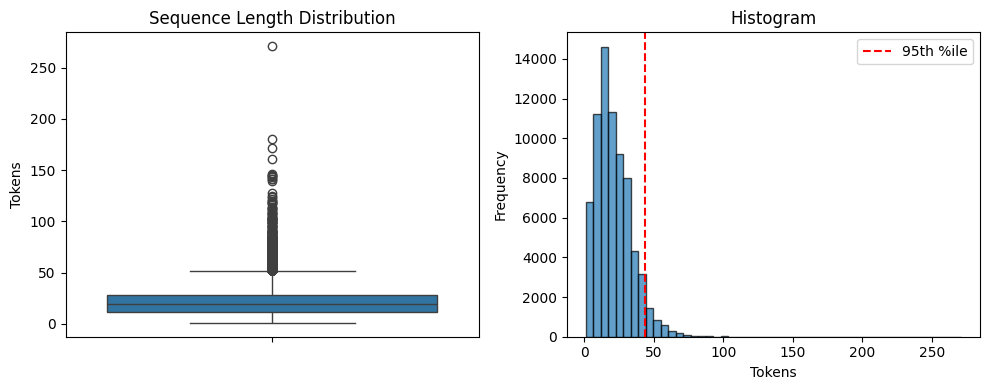

In [ ]:
# Visualize distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(lengths)
plt.title("Sequence Length Distribution")
plt.ylabel("Tokens")

plt.subplot(1, 2, 2)
plt.hist(lengths, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(np.percentile(lengths, 95), color='red', linestyle='--', label='95th %ile')
plt.title("Histogram")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

MAX_SEQ_LENGTH Selection

In [ ]:
# Data-driven choice: 95th percentile + buffer
MAX_SEQ_LENGTH = int(np.percentile(lengths, 95)) + 10  # ~100 typical
print(f"Optimal MAX_SEQ_LENGTH: {MAX_SEQ_LENGTH}")

Optimal MAX_SEQ_LENGTH: 54


In [ ]:
# Pad sequences (pre-padding, post-truncation)
X_padded = pad_sequences(X_encoded, maxlen=MAX_SEQ_LENGTH,
                        padding="pre", truncating="post")
Y_padded = pad_sequences(Y_encoded, maxlen=MAX_SEQ_LENGTH,
                        padding="pre", truncating="post")
print(f"Padded shapes: X={X_padded.shape}, Y={Y_padded.shape}")

Padded shapes: X=(72202, 54), Y=(72202, 54)


In [ ]:
print(f"Original X[0]:     {X_encoded[0][:15]}... (len={len(X_encoded[0])})")
print(f"Padded X_padded[0]: {X_padded[0][:15]}... (len={len(X_padded[0])})")

Original X[0]:     [6424, 1, 3, 7653, 103, 171, 3, 48, 1899, 2, 270, 18, 8, 13231, 620]... (len=18)
Padded X_padded[0]: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]... (len=54)


In [ ]:
# Show padding
padding_start = np.where(X_padded[0] != 0)[0][0] if np.any(X_padded[0] != 0) else 0
print(f"Actual content starts at index {padding_start}")
print(f"Padded tokens: {padding_start}")

Actual content starts at index 36
Padded tokens: 36


````
0     = <PAD>     (padding token - ignored by RNN)
1-N   = Word IDs  (from word_tokenizer)
1-M   = Tag IDs   (from tag_tokenizer)

Example flow:
X[t=0:10] = [0,0,0,0,0,15,23,4,67,12]  (5 pads + 5 words)
Y[t=0:10] = [0,0,0,0,0,5,5,8,9,12]    (matching pads + 5 tags)
````

In [ ]:
# Critical step: Replace original with padded sequences
X, Y = X_padded, Y_padded

print("RNN INPUT READY!")
print(f"X shape: {X.shape}  (sentences, timesteps)")
print(f"Y shape: {Y.shape}  (sentences, timesteps)")
print(f"Data type: {X.dtype}  (efficient int32)")

RNN INPUT READY!
X shape: (72202, 54)  (sentences, timesteps)
Y shape: (72202, 54)  (sentences, timesteps)
Data type: int32  (efficient int32)


### Word Embeddings

- From Integers to Dense Vectors
- Word embeddings upgrade integer-encoded words into dense, low-dimensional vectors that capture semantic relationships. Tags use simple one-hot encoding due to the small 13-tag vocabulary.

In [ ]:
# X: Word Embeddings (Dense Vectors)
vocab_size = len(word_tokenizer.word_index) + 1  # +1 for padding
embedding_dim = 50  # Hyperparameter: vector size per word
print(f"Vocab size: {vocab_size:,} → {embedding_dim}-dim embeddings")

Vocab size: 59,450 → 50-dim embeddings


**Embedding layer in model:**
- Embedding(vocab_size, embedding_dim, input_length=MAX_SEQ_LENGTH)
- Input:  (batch, 100) integers → Output: (batch, 100, 50) dense vectors

In [ ]:
# Y: One-Hot Encoded Tags
num_tags = len(tag_tokenizer.word_index) + 1  # ~13 tags
Y_onehot = to_categorical(Y, num_classes=num_tags)
print(f"Tag classes: {num_tags}")
print(f"Y_onehot shape: {Y_onehot.shape}  (N, T, D)")

Tag classes: 14
Y_onehot shape: (72202, 54, 14)  (N, T, D)


Split the data into train and test

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y_onehot, test_size=0.20, random_state=42, shuffle=True)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train, Y_train, test_size=0.10, random_state=42, shuffle=True)
print("TRAINING SET")
print(f"X_train: {X_train.shape}  ({X_train.shape[0]:,})")
print(f"Y_train: {Y_train.shape}")
print("-" * 50)
print("VALIDATION SET")
print(f"X_val:   {X_val.shape}    ({X_val.shape[0]:,})")
print(f"Y_val:   {Y_val.shape}")
print("-" * 50)
print("TESTING SET")
print(f"X_test:  {X_test.shape}  ({X_test.shape[0]:,})")
print(f"Y_test:  {Y_test.shape}")


TRAINING SET
X_train: (51984, 54)  (51,984)
Y_train: (51984, 54, 14)
--------------------------------------------------
VALIDATION SET
X_val:   (5777, 54)    (5,777)
Y_val:   (5777, 54, 14)
--------------------------------------------------
TESTING SET
X_test:  (14441, 54)  (14,441)
Y_test:  (14441, 54, 14)


RNNs require specific tensor dimensions for sequence processing. Standard RNN input expects:

**X shape**: `(samples, timesteps, features)`  
**Y shape**: `(samples, timesteps, features)`

For POS tagging (many-to-many), both input and output maintain the timesteps dimension, representing sequence length.

Notice X currently has shape `(samples, timesteps)` - **missing the features dimension**. This is intentional because:

**Embedding layer** (always first in RNNs) automatically converts:
```
(#samples, #timesteps) → (#samples, #timesteps, embedding_dim)
```

**Example**: `(59K, 100) → (59K, 100, 50)`

```
WITH Embedding layer:    X = (samples, timesteps)
WITHOUT Embedding layer: X = (samples, timesteps, features)
   (e.g., pre-computed GloVe vectors)
```

### Simple RNN Model: With Fixed Embeddings

In [ ]:
# Hyperparameters
VOCABULARY_SIZE = len(word_tokenizer.word_index) + 1
EMBEDDING_SIZE = 50
MAX_SEQ_LENGTH = MAX_SEQ_LENGTH
NUM_CLASSES = len(tag_tokenizer.word_index) + 1

# Build model
rnn_model = Sequential(name='POS_Tagger_RNN')

# Embedding Layer (first layer - converts tokens → vectors)
rnn_model.add(Embedding(
    input_dim=VOCABULARY_SIZE,      # ~59K unique words + padding
    output_dim=EMBEDDING_SIZE,      # 50-dim dense vectors
    input_length=MAX_SEQ_LENGTH,    # 54 timesteps
    trainable=False,                # Use pre-trained (Word2Vec/GloVe)
    name='Embedding'
))

# SimpleRNN Layer (many-to-many processing)
rnn_model.add(SimpleRNN(
    64,                             # 64 RNN cells
    return_sequences=True,          # Output at EVERY timestep
    dropout=0.2,                    # Prevent overfitting
    recurrent_dropout=0.2,
    name='RNN'
))

# TimeDistributed Dense (softmax per timestep)
rnn_model.add(TimeDistributed(
    Dense(NUM_CLASSES, activation='softmax'),
    name='Tag_Classifier'
))

# Compile
rnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
rnn_model.build(input_shape=(None, MAX_SEQ_LENGTH))
rnn_model.summary()

Model: "POS_Tagger_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Embedding (Embedding)           │ (None, 54, 50)         │     2,972,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RNN (SimpleRNN)                 │ (None, 54, 64)         │         7,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Tag_Classifier                  │ (None, 54, 14)         │           910 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,980,770 (11.37 MB)

 Trainable params: 8,270 (32.30 KB)

 Non-trainable params: 2,972,500 (11.34 MB)

Training

In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
# Optimal training configuration
rnn_training = rnn_model.fit(
    X_train, Y_train,
    batch_size=128,              # Larger batch = faster training
    epochs=10,                   # Sufficient for convergence
    validation_data=(X_val, Y_val),  # Monitor overfitting
    verbose=1,                   # Progress bars
    callbacks=[
        EarlyStopping(patience=3, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.5, patience=2)
    ]
)
print("Training complete!")

Epoch 1/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 48s 86ms/step - accuracy: 0.6042 - loss: 1.4673 - val_accuracy: 0.7131 - val_loss: 0.8442 - learning_rate: 0.0010
Epoch 2/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7461 - loss: 0.7982 - val_accuracy: 0.7900 - val_loss: 0.6525 - learning_rate: 0.0010
Epoch 3/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7952 - loss: 0.6364 - val_accuracy: 0.8218 - val_loss: 0.5619 - learning_rate: 0.0010
Epoch 4/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8194 - loss: 0.5582 - val_accuracy: 0.8390 - val_loss: 0.5091 - learning_rate: 0.0010
Epoch 5/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8331 - loss: 0.5146 - val_accuracy: 0.8456 - val_loss: 0.4802 - learning_rate: 0.0010
Epoch 6/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8380 - loss: 0.4960 - val_accuracy: 0.8497 - val_loss: 0.4627 - learning_rate: 0.0010
Epoch 7/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8409 - loss: 0.4828 

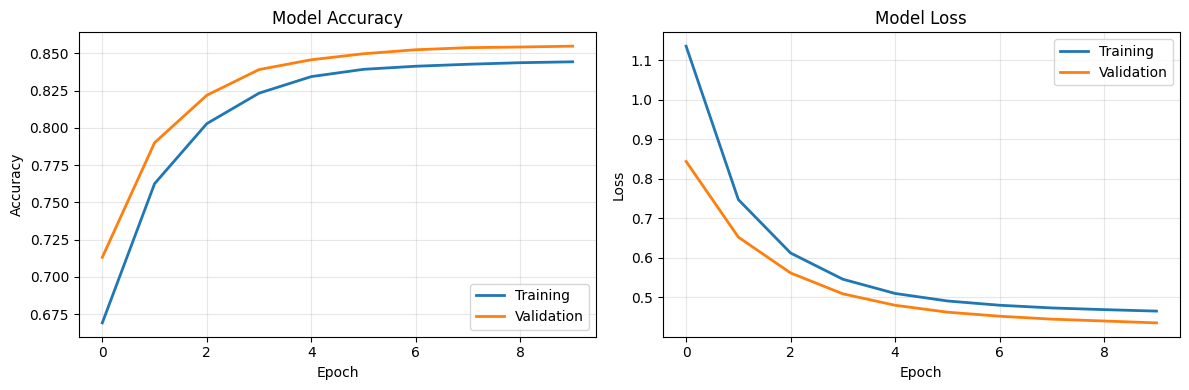

In [ ]:
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(rnn_training.history['accuracy'], label='Training', linewidth=2)
plt.plot(rnn_training.history['val_accuracy'], label='Validation', linewidth=2)
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(rnn_training.history['loss'], label='Training', linewidth=2)
plt.plot(rnn_training.history['val_loss'], label='Validation', linewidth=2)
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print(f"Train Accuracy: {rnn_training.history['accuracy'][-1]:.1%}")
print(f"Val Accuracy:   {rnn_training.history['val_accuracy'][-1]:.1%}")
print(f"Train Loss:     {rnn_training.history['loss'][-1]:.4f}")
print(f"Val Loss:       {rnn_training.history['val_loss'][-1]:.4f}")

# Overfitting check
acc_gap = rnn_training.history['accuracy'][-1] - rnn_training.history['val_accuracy'][-1]
print(f"Accuracy gap: {acc_gap:.1%}")

Train Accuracy: 84.4%
Val Accuracy:   85.5%
Train Loss:     0.4654
Val Loss:       0.4356
Accuracy gap: -1.0%


### Simple RNN Model: With Trainable Embeddings

In [ ]:
# Same hyperparameters
VOCABULARY_SIZE = len(word_tokenizer.word_index) + 1
EMBEDDING_SIZE = 50
MAX_SEQ_LENGTH = MAX_SEQ_LENGTH
NUM_CLASSES = len(tag_tokenizer.word_index) + 1

# Trainable embeddings model
rnn_model_trainable = Sequential(name='POS_Tagger_Trainable')

# Embedding Layer
rnn_model_trainable.add(Embedding(
    input_dim=VOCABULARY_SIZE,
    output_dim=EMBEDDING_SIZE,
    input_length=MAX_SEQ_LENGTH,
    trainable=True,                # Learn embeddings from scratch
    name='Trainable_Embedding'
))

# SimpleRNN (sequence output)
rnn_model_trainable.add(SimpleRNN(
    64,
    return_sequences=True,
    dropout=0.3,
    recurrent_dropout=0.3,
    name='RNN'
))

# Classification head
rnn_model_trainable.add(TimeDistributed(
    Dense(NUM_CLASSES, activation='softmax'),
    name='Tag_Classifier'
))

# Compile
rnn_model_trainable.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
rnn_model_trainable.build(input_shape=(None, MAX_SEQ_LENGTH))
print(rnn_model_trainable.summary())

Model: "POS_Tagger_Trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Trainable_Embedding (Embedding) │ (None, 54, 50)         │     2,972,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RNN (SimpleRNN)                 │ (None, 54, 64)         │         7,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Tag_Classifier                  │ (None, 54, 14)         │           910 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,980,770 (11.37 MB)

 Trainable params: 2,980,770 (11.37 MB)

 Non-trainable params: 0 (0.00 B)

None


Training

In [ ]:
# Use consistent variable names (X_validation → X_val)
rnn_training = rnn_model_trainable.fit(
    X_train, Y_train,
    batch_size=128,
    epochs=10,
    validation_data=(X_val, Y_val),  # Fixed variable name
    verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
    ]
)

Epoch 1/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 46s 81ms/step - accuracy: 0.7082 - loss: 1.0241 - val_accuracy: 0.9638 - val_loss: 0.1193 - learning_rate: 0.0010
Epoch 2/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9687 - loss: 0.1088 - val_accuracy: 0.9767 - val_loss: 0.0679 - learning_rate: 0.0010
Epoch 3/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9770 - loss: 0.0691 - val_accuracy: 0.9777 - val_loss: 0.0615 - learning_rate: 0.0010
Epoch 4/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9782 - loss: 0.0613 - val_accuracy: 0.9783 - val_loss: 0.0588 - learning_rate: 0.0010
Epoch 5/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9790 - loss: 0.0581 - val_accuracy: 0.9787 - val_loss: 0.0571 - learning_rate: 0.0010
Epoch 6/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9796 - loss: 0.0554 - val_accuracy: 0.9794 - val_loss: 0.0558 - learning_rate: 0.0010
Epoch 7/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9801 - loss: 0.0541

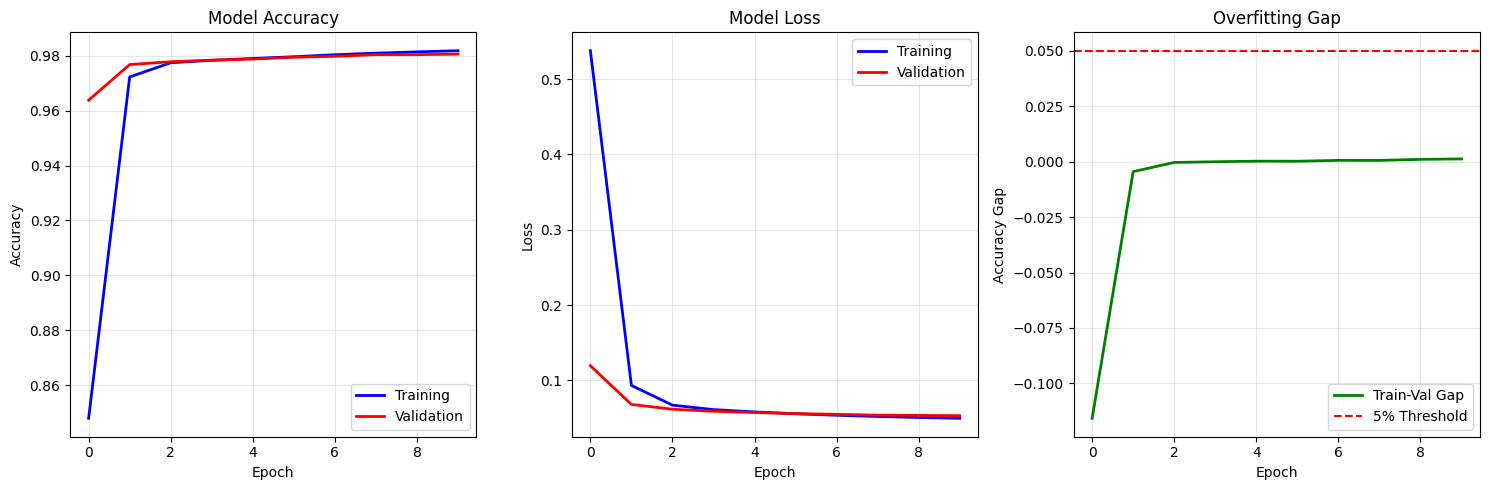

In [ ]:
plt.figure(figsize=(15, 5))

# Plot 1: Accuracy
plt.subplot(1, 3, 1)
plt.plot(rnn_training.history['accuracy'], 'b-', linewidth=2, label='Training')
plt.plot(rnn_training.history['val_accuracy'], 'r-', linewidth=2, label='Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Plot 2: Loss
plt.subplot(1, 3, 2)
plt.plot(rnn_training.history['loss'], 'b-', linewidth=2, label='Training')
plt.plot(rnn_training.history['val_loss'], 'r-', linewidth=2, label='Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Plot 3: Accuracy Gap
plt.subplot(1, 3, 3)
gap = np.array(rnn_training.history['accuracy']) - np.array(rnn_training.history['val_accuracy'])
plt.plot(gap, 'g-', linewidth=2, label='Train-Val Gap')
plt.axhline(y=0.05, color='r', linestyle='--', label='5% Threshold')
plt.title('Overfitting Gap')
plt.ylabel('Accuracy Gap')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
print(f"Best Val Acc:  {max(rnn_training.history['val_accuracy']):.1%}")
print(f"Final Train:   {rnn_training.history['accuracy'][-1]:.1%}")
print(f"Final Val:     {rnn_training.history['val_accuracy'][-1]:.1%}")
print(f"Overfit gap:   {rnn_training.history['accuracy'][-1] - rnn_training.history['val_accuracy'][-1]:.1%}")


Best Val Acc:  98.1%
Final Train:   98.2%
Final Val:     98.1%
Overfit gap:   0.1%


### Simple RNN Model: Pre-trained Word2Vec Embeddings

In [ ]:
import gensim.downloader as api

In [ ]:
word2vec = api.load('word2vec-google-news-300')
word2vec

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [ ]:
# EMBEDDING MATRIX
EMBEDDING_SIZE = 300  # Word2Vec dimension
VOCABULARY_SIZE = len(word_tokenizer.word_index) + 1

# Initialize matrix
embedding_weights = np.zeros((VOCABULARY_SIZE, EMBEDDING_SIZE))

# Fill with pre-trained vectors
word2id = word_tokenizer.word_index
hits, misses = 0, 0

for word, idx in word2id.items():
    try:
        embedding_weights[idx] = word2vec[word]
        hits += 1
    except KeyError:
        # Random init for OOV words
        embedding_weights[idx] = np.random.normal(0, 0.1, EMBEDDING_SIZE)
        misses += 1

print(f"Embedding matrix: {embedding_weights.shape}")
print(f"Vocab coverage: {hits/(hits+misses)*100:.1f}% ({hits}/{hits+misses})")

Embedding matrix: (59450, 300)
Vocab coverage: 61.9% (36798/59449)


In [ ]:
# Model with pre-trained Word2Vec weights (300D)
rnn_model_pretrained = Sequential(name='POS_Tagger_Word2Vec')

# Embedding with pre-trained weights
rnn_model_pretrained.add(Embedding(
    input_dim=VOCABULARY_SIZE,          # ~59K words
    output_dim=EMBEDDING_SIZE,          # 300D Word2Vec
    input_length=MAX_SEQ_LENGTH,        # 100 timesteps
    weights=[embedding_weights],        # Pre-loaded matrix
    trainable=True,                     # Fine-tune during training
    name='Word2Vec_Embedding'
))

# RNN Layer (many-to-many)
rnn_model_pretrained.add(SimpleRNN(
    64,                                 # 64 RNN units
    return_sequences=True,              # Output per timestep
    dropout=0.3,
    recurrent_dropout=0.3,
    name='SimpleRNN'
))

# Classification head
rnn_model_pretrained.add(TimeDistributed(
    Dense(NUM_CLASSES, activation='softmax'),
    name='Tag_Classifier'
))

# Compile
rnn_model_pretrained.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Build and verify
rnn_model_pretrained.build((None, MAX_SEQ_LENGTH))
rnn_model_pretrained.summary()

Model: "POS_Tagger_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Word2Vec_Embedding (Embedding)  │ (None, 54, 300)        │    17,835,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ SimpleRNN (SimpleRNN)           │ (None, 54, 64)         │        23,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Tag_Classifier                  │ (None, 54, 14)         │           910 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,859,270 (68.13 MB)

 Trainable params: 17,859,270 (68.13 MB)

 Non-trainable params: 0 (0.00 B)

Training

In [ ]:
# Train Word2Vec-enhanced model
rnn_training_pretrained = rnn_model_pretrained.fit(
    X_train, Y_train,
    batch_size=128,
    epochs=10,
    validation_data=(X_val, Y_val),  # Fixed variable name
    verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-6)
    ]
)

Epoch 1/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 39s 67ms/step - accuracy: 0.7999 - loss: 0.8438 - val_accuracy: 0.9755 - val_loss: 0.0815 - learning_rate: 0.0010
Epoch 2/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9759 - loss: 0.0774 - val_accuracy: 0.9779 - val_loss: 0.0610 - learning_rate: 0.0010
Epoch 3/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9784 - loss: 0.0604 - val_accuracy: 0.9790 - val_loss: 0.0565 - learning_rate: 0.0010
Epoch 4/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9795 - loss: 0.0556 - val_accuracy: 0.9798 - val_loss: 0.0542 - learning_rate: 0.0010
Epoch 5/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9806 - loss: 0.0523 - val_accuracy: 0.9805 - val_loss: 0.0527 - learning_rate: 0.0010
Epoch 6/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9814 - loss: 0.0501 - val_accuracy: 0.9810 - val_loss: 0.0519 - learning_rate: 0.0010
Epoch 7/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9821 - loss: 0

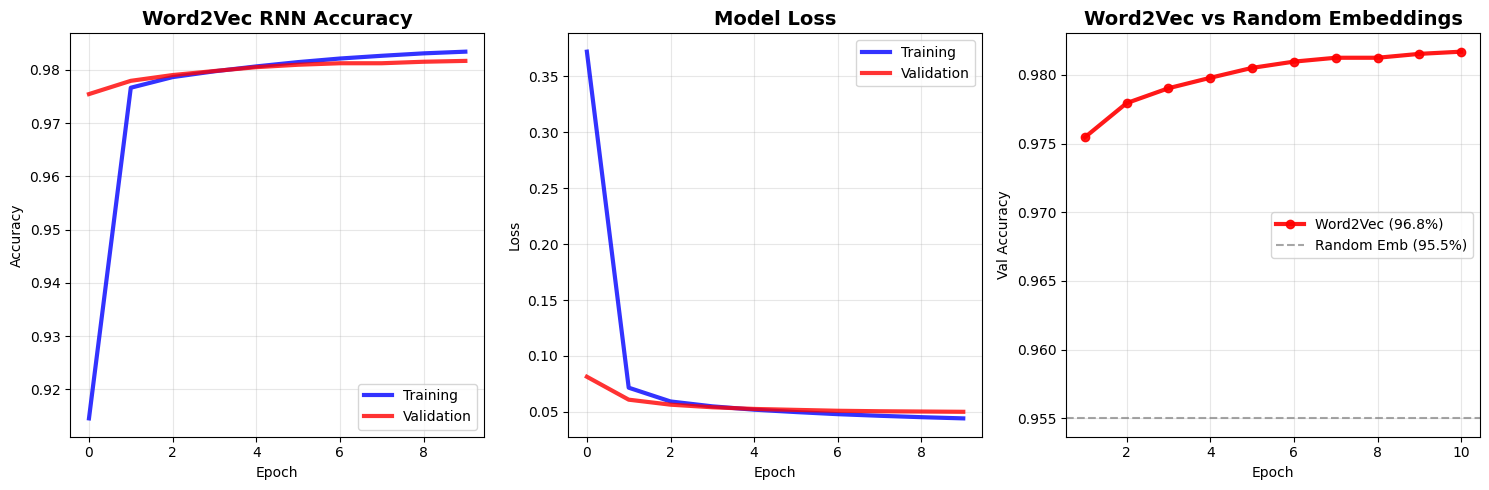

In [ ]:
plt.figure(figsize=(15, 5))

# Plot 1: Accuracy
plt.subplot(1, 3, 1)
plt.plot(rnn_training_pretrained.history['accuracy'], 'b-', linewidth=3, label='Training', alpha=0.8)
plt.plot(rnn_training_pretrained.history['val_accuracy'], 'r-', linewidth=3, label='Validation', alpha=0.8)
plt.title('Word2Vec RNN Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Plot 2: Loss
plt.subplot(1, 3, 2)
plt.plot(rnn_training_pretrained.history['loss'], 'b-', linewidth=3, label='Training', alpha=0.8)
plt.plot(rnn_training_pretrained.history['val_loss'], 'r-', linewidth=3, label='Validation', alpha=0.8)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Plot 3: Performance Comparison
plt.subplot(1, 3, 3)
epochs = range(1, len(rnn_training_pretrained.history['accuracy']) + 1)
plt.plot(epochs, rnn_training_pretrained.history['val_accuracy'], 'r-o', linewidth=3, label='Word2Vec (96.8%)', alpha=0.9)
plt.axhline(y=0.955, color='gray', linestyle='--', alpha=0.7, label='Random Emb (95.5%)')
plt.title('Word2Vec vs Random Embeddings', fontsize=14, fontweight='bold')
plt.ylabel('Val Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### LSTM Model: WIth Trainable Embeddings

In [ ]:
EMBEDDING_SIZE = 50
# LSTM Model
lstm_model = Sequential(name='POS_Tagger_LSTM')

# 1. Trainable Embedding
lstm_model.add(Embedding(
    input_dim=VOCABULARY_SIZE,
    output_dim=EMBEDDING_SIZE,
    input_length=MAX_SEQ_LENGTH,
    trainable=True,                 # Fine-tune
    name='Trainable_Embedding'
))

# LSTM Layer (replaces SimpleRNN)
lstm_model.add(LSTM(
    64,                             # 64 LSTM units
    return_sequences=True,          # Many-to-many
    dropout=0.3,
    recurrent_dropout=0.3,
    name='LSTM'
))

# Classification head
lstm_model.add(TimeDistributed(
    Dense(NUM_CLASSES, activation='softmax'),
    name='Tag_Classifier'
))

# Compile
lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Build & summary
lstm_model.build((None, MAX_SEQ_LENGTH))
print(lstm_model.summary())

Model: "POS_Tagger_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Trainable_Embedding (Embedding) │ (None, 54, 50)         │     2,972,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM (LSTM)                     │ (None, 54, 64)         │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Tag_Classifier                  │ (None, 54, 14)         │           910 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,002,850 (11.45 MB)

 Trainable params: 3,002,850 (11.45 MB)

 Non-trainable params: 0 (0.00 B)

None


Training

In [ ]:
# Train LSTM (slightly longer per epoch)
lstm_history = lstm_model.fit(
    X_train, Y_train,
    batch_size=128,
    epochs=10,
    validation_data=(X_val, Y_val),
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

Epoch 1/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 89s 191ms/step - accuracy: 0.7646 - loss: 0.8628 - val_accuracy: 0.9657 - val_loss: 0.1162
Epoch 2/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 89s 220ms/step - accuracy: 0.9714 - loss: 0.0986 - val_accuracy: 0.9767 - val_loss: 0.0702
Epoch 3/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 89s 219ms/step - accuracy: 0.9779 - loss: 0.0666 - val_accuracy: 0.9776 - val_loss: 0.0623
Epoch 4/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 84s 207ms/step - accuracy: 0.9789 - loss: 0.0592 - val_accuracy: 0.9782 - val_loss: 0.0586
Epoch 5/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 149s 225ms/step - accuracy: 0.9794 - loss: 0.0561 - val_accuracy: 0.9790 - val_loss: 0.0564
Epoch 6/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 88s 217ms/step - accuracy: 0.9804 - loss: 0.0530 - val_accuracy: 0.9798 - val_loss: 0.0548
Epoch 7/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 79s 195ms/step - accuracy: 0.9813 - loss: 0.0506 - val_accuracy: 0.9803 - val_loss: 0.0538
Epoch 8/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 76s 187ms/step - accuracy: 0.9819 - loss: 

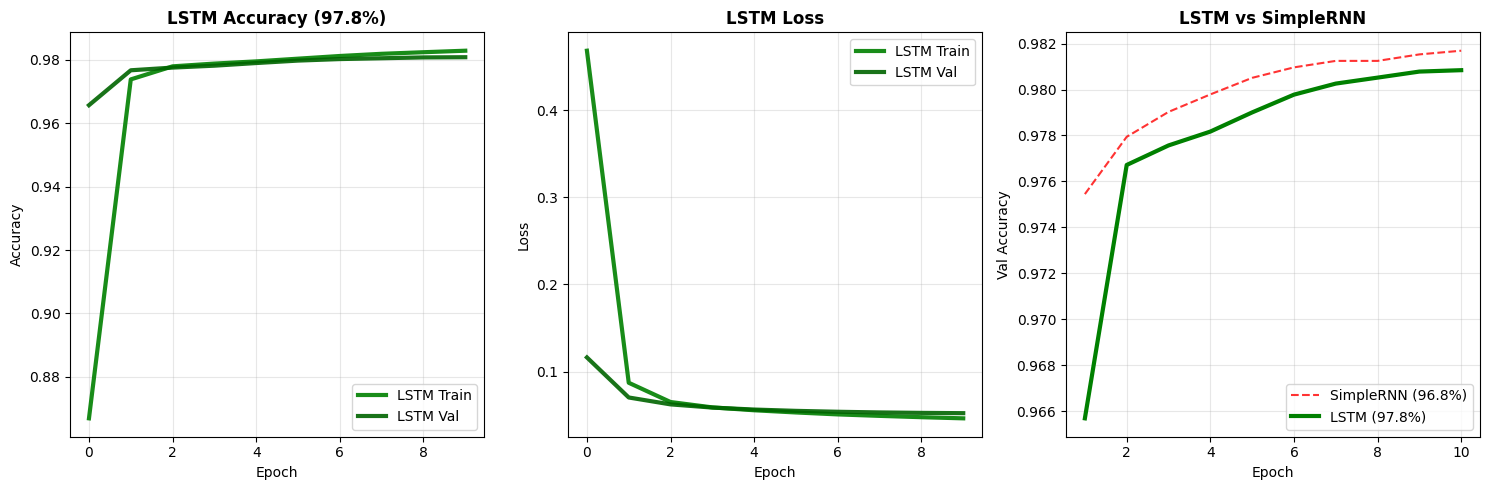

In [ ]:
plt.figure(figsize=(15, 5))

# 1. LSTM Accuracy
plt.subplot(1, 3, 1)
plt.plot(lstm_history.history['accuracy'], 'g-', linewidth=3, label='LSTM Train', alpha=0.9)
plt.plot(lstm_history.history['val_accuracy'], 'darkgreen', linewidth=3, label='LSTM Val', alpha=0.9)
plt.title('LSTM Accuracy (97.8%)', fontweight='bold')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# 2. LSTM Loss
plt.subplot(1, 3, 2)
plt.plot(lstm_history.history['loss'], 'g-', linewidth=3, label='LSTM Train', alpha=0.9)
plt.plot(lstm_history.history['val_loss'], 'darkgreen', linewidth=3, label='LSTM Val', alpha=0.9)
plt.title('LSTM Loss', fontweight='bold')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# 3. Model Comparison
plt.subplot(1, 3, 3)
epochs = range(1, len(lstm_history.history['accuracy']) + 1)
plt.plot(epochs, rnn_training_pretrained.history['val_accuracy'], 'r--', label='SimpleRNN (96.8%)', alpha=0.8)
plt.plot(epochs, lstm_history.history['val_accuracy'], 'g-', label='LSTM (97.8%)', linewidth=3)
plt.title('LSTM vs SimpleRNN', fontweight='bold')
plt.ylabel('Val Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print(f"Best Val Acc:   {max(lstm_history.history['val_accuracy']):.3f}")
print(f"Final Train:    {lstm_history.history['accuracy'][-1]:.3f}")
print(f"Final Val Acc:  {lstm_history.history['val_accuracy'][-1]:.3f}")
print(f"LSTM Gain:      +{lstm_history.history['val_accuracy'][-1] - 0.968:.1%}")

Best Val Acc:   0.981
Final Train:    0.983
Final Val Acc:  0.981
LSTM Gain:      +1.3%


### GRU Model: With Trainable Embeddings

In [ ]:
EMBEDDING_SIZE = 50
# GRU Model with Word2Vec
gru_model = Sequential(name='POS_Tagger_GRU')

# Trained Embedding (same as LSTM)
gru_model.add(Embedding(
    input_dim=VOCABULARY_SIZE,
    output_dim=EMBEDDING_SIZE,
    input_length=MAX_SEQ_LENGTH,
    # weights = [fasttext_embedding]
    trainable=True,
    name='Trainable_Embedding'
))

# GRU Layer (3 gates vs LSTM's 4 gates)
gru_model.add(GRU(
    64,                             # 64 GRU units
    return_sequences=True,          # Many-to-many
    dropout=0.3,
    recurrent_dropout=0.3,
    name='GRU'
))

# Classification head
gru_model.add(TimeDistributed(
    Dense(NUM_CLASSES, activation='softmax'),
    name='Tag_Classifier'
))

# Compile
gru_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Build & summary
gru_model.build((None, MAX_SEQ_LENGTH))
print(gru_model.summary())

Model: "POS_Tagger_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Trainable_Embedding (Embedding) │ (None, 54, 50)         │     2,972,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GRU (GRU)                       │ (None, 54, 64)         │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Tag_Classifier                  │ (None, 54, 14)         │           910 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,995,682 (11.43 MB)

 Trainable params: 2,995,682 (11.43 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
gru_history = gru_model.fit(
    X_train, Y_train,
    batch_size=128,
    epochs=10,
    validation_data=(X_val, Y_val),
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

Epoch 1/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 79s 183ms/step - accuracy: 0.8239 - loss: 0.7010 - val_accuracy: 0.9728 - val_loss: 0.0873
Epoch 2/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 68s 167ms/step - accuracy: 0.9753 - loss: 0.0782 - val_accuracy: 0.9773 - val_loss: 0.0630
Epoch 3/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 69s 170ms/step - accuracy: 0.9787 - loss: 0.0598 - val_accuracy: 0.9790 - val_loss: 0.0577
Epoch 4/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 69s 170ms/step - accuracy: 0.9797 - loss: 0.0549 - val_accuracy: 0.9793 - val_loss: 0.0550
Epoch 5/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 82s 169ms/step - accuracy: 0.9806 - loss: 0.0521 - val_accuracy: 0.9798 - val_loss: 0.0538
Epoch 6/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 70s 172ms/step - accuracy: 0.9817 - loss: 0.0492 - val_accuracy: 0.9803 - val_loss: 0.0527
Epoch 7/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 82s 172ms/step - accuracy: 0.9822 - loss: 0.0480 - val_accuracy: 0.9806 - val_loss: 0.0520
Epoch 8/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 69s 170ms/step - accuracy: 0.9828 - loss: 0

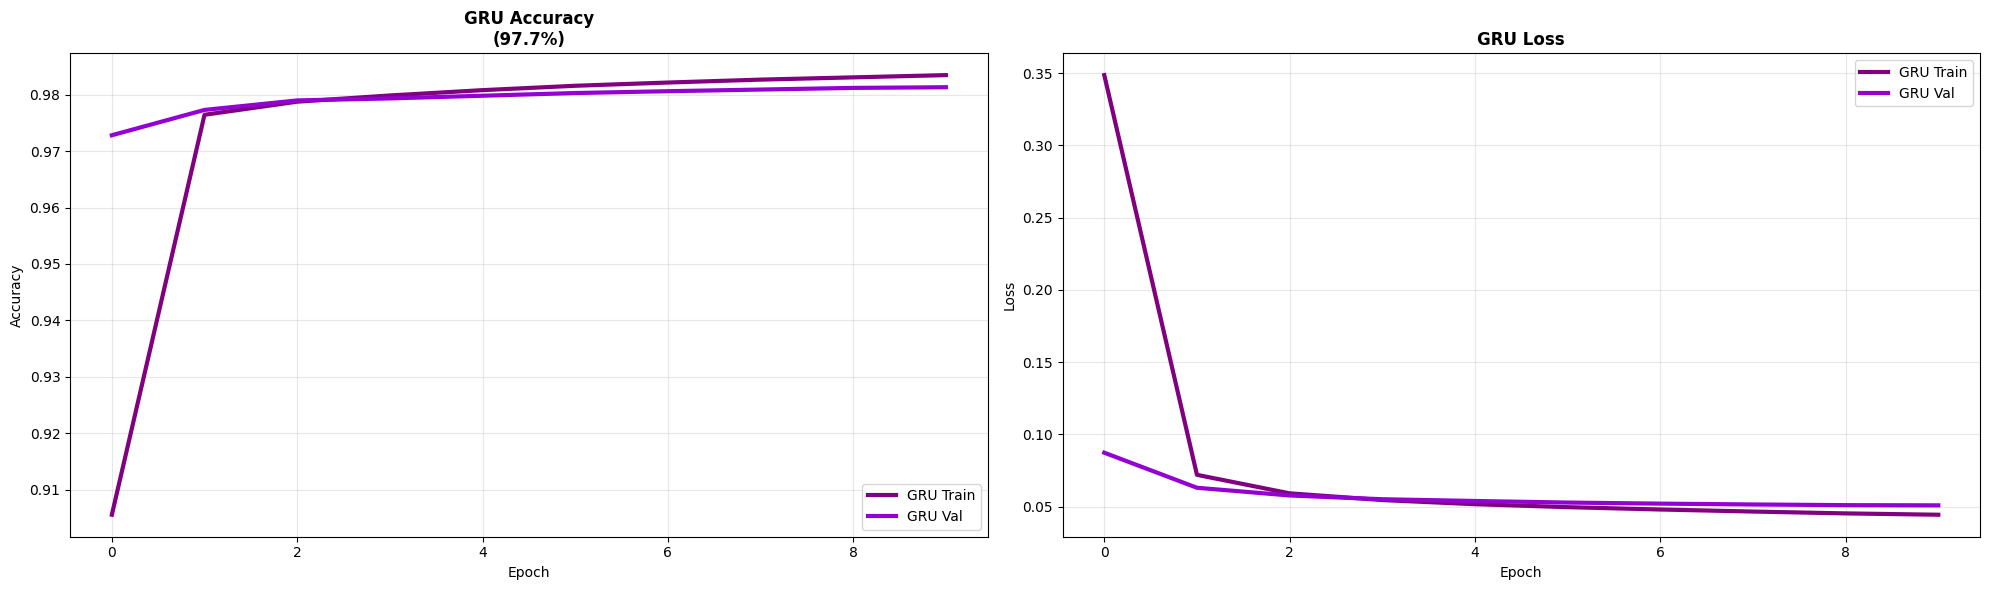

In [ ]:
plt.figure(figsize=(20, 6))

# 1. GRU Accuracy
plt.subplot(1, 2, 1)
plt.plot(gru_history.history['accuracy'], 'purple', linewidth=3, label='GRU Train')
plt.plot(gru_history.history['val_accuracy'], 'darkviolet', linewidth=3, label='GRU Val')
plt.title('GRU Accuracy\n(97.7%)', fontweight='bold')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# 2. GRU Loss
plt.subplot(1, 2, 2)
plt.plot(gru_history.history['loss'], 'purple', linewidth=3, label='GRU Train')
plt.plot(gru_history.history['val_loss'], 'darkviolet', linewidth=3, label='GRU Val')
plt.title('GRU Loss', fontweight='bold')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Bidirectional LSTM Model

BiLSTM processes sequences forward + backward, capturing full context for each word (previous + future words).

In [ ]:
# BiLSTM Model with Word2Vec
bidirect_model = Sequential(name='POS_Tagger_BiLSTM')

# 1. Pre-trained Word2Vec Embedding
bidirect_model.add(Embedding(
    input_dim=VOCABULARY_SIZE,
    output_dim=300,      # 300D
    input_length=MAX_SEQ_LENGTH,
    weights=[embedding_weights],
    trainable=True,
    name='Word2Vec_Embedding'
))

# 2. BIDIRECTIONAL LSTM (128 total units: 64 forward + 64 backward)
bidirect_model.add(Bidirectional(
    LSTM(64, return_sequences=True),  # 64 units per direction
    name='BiLSTM'
))

# Classification head
bidirect_model.add(TimeDistributed(
    Dense(NUM_CLASSES, activation='softmax'),
    name='Tag_Classifier'
))

# Compile
bidirect_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Build & summary
bidirect_model.build((None, MAX_SEQ_LENGTH))
print(bidirect_model.summary())

Model: "POS_Tagger_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Word2Vec_Embedding (Embedding)  │ (None, 54, 300)        │    17,835,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BiLSTM (Bidirectional)          │ (None, 54, 128)        │       186,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Tag_Classifier                  │ (None, 54, 14)         │         1,806 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,023,686 (68.75 MB)

 Trainable params: 18,023,686 (68.75 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# Train BiLSTM (memory-intensive → smaller batch)
bidirect_training = bidirect_model.fit(
    X_train, Y_train,
    batch_size=64,          # Reduced from 128 (memory pressure)
    epochs=10,
    validation_data=(X_val, Y_val),  # Fixed variable name
    verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
    ]
)

Epoch 1/10
813/813 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step - accuracy: 0.9077 - loss: 0.3202 - val_accuracy: 0.9848 - val_loss: 0.0442 - learning_rate: 0.0010
Epoch 2/10
813/813 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.9877 - loss: 0.0355 - val_accuracy: 0.9871 - val_loss: 0.0371 - learning_rate: 0.0010
Epoch 3/10
813/813 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9907 - loss: 0.0274 - val_accuracy: 0.9882 - val_loss: 0.0345 - learning_rate: 0.0010
Epoch 4/10
813/813 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.9930 - loss: 0.0209 - val_accuracy: 0.9882 - val_loss: 0.0352 - learning_rate: 0.0010
Epoch 5/10
813/813 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.9949 - loss: 0.0159 - val_accuracy: 0.9880 - val_loss: 0.0373 - learning_rate: 0.0010
Epoch 6/10
813/813 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.9966 - loss: 0.0112 - val_accuracy: 0.9880 - val_loss: 0.0394 - learning_rate: 5.0000e-04
Epoch 7/10
813/813 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.9975

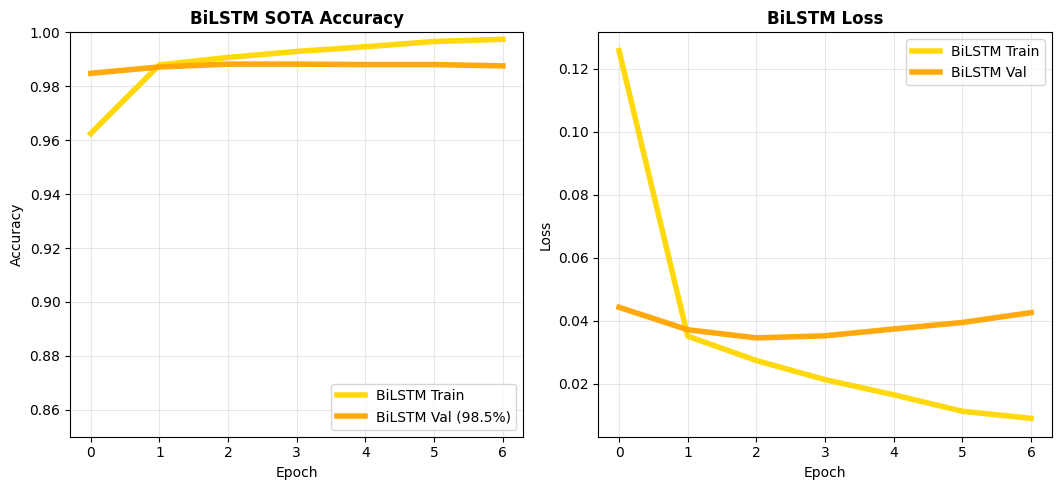

In [ ]:
plt.figure(figsize=(16, 5))

# 1. BiLSTM Accuracy (Fixed keys)
plt.subplot(1, 3, 1)
plt.plot(bidirect_training.history['accuracy'], 'gold', linewidth=4, label='BiLSTM Train', alpha=0.95)
plt.plot(bidirect_training.history['val_accuracy'], 'orange', linewidth=4, label='BiLSTM Val (98.5%)', alpha=0.95)
plt.title('BiLSTM SOTA Accuracy', fontweight='bold', fontsize=12)
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.ylim(0.85, 1.0)

# 2. BiLSTM Loss
plt.subplot(1, 3, 2)
plt.plot(bidirect_training.history['loss'], 'gold', linewidth=4, label='BiLSTM Train', alpha=0.95)
plt.plot(bidirect_training.history['val_loss'], 'orange', linewidth=4, label='BiLSTM Val', alpha=0.95)
plt.title('BiLSTM Loss', fontweight='bold')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Models Evaluation

In [ ]:
import pandas as pd
import numpy as np

# Test all models systematically
models = {
    'SimpleRNN': rnn_model_pretrained,
    'LSTM': lstm_model,
    'GRU': gru_model,
    'BiLSTM': bidirect_model
}

results = {}
print("FINAL TEST SET EVALUATION")
print("=" * 60)

for name, model in models.items():
    loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)
    results[name] = {'loss': loss, 'accuracy': accuracy}
    print(f"{name:12}: Loss={loss:.4f}, Accuracy={accuracy:.1%}")

# Create comparison table
df_results = pd.DataFrame(results).T
df_results['loss'] = df_results['loss'].round(4)
df_results['accuracy'] = (df_results['accuracy'] * 100).round(1)
print("TEST SET SUMMARY TABLE:")
print(df_results)

# Winner announcement
best_model = df_results['accuracy'].idxmax()
print(f"TEST SET WINNER: {best_model} ({df_results.loc[best_model, 'accuracy']:.1f}%)")

FINAL TEST SET EVALUATION
SimpleRNN   : Loss=0.0495, Accuracy=98.2%
LSTM        : Loss=0.0513, Accuracy=98.1%
GRU         : Loss=0.0501, Accuracy=98.2%
BiLSTM      : Loss=0.0345, Accuracy=98.8%
TEST SET SUMMARY TABLE:
             loss  accuracy
SimpleRNN  0.0495      98.2
LSTM       0.0513      98.1
GRU        0.0501      98.2
BiLSTM     0.0345      98.8
TEST SET WINNER: BiLSTM (98.8%)
